# cmip comparison figure and supplementary 

 

In [33]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [34]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm
import glob
import xarray as xr
from pathlib import Path
from scipy import stats

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


In [35]:
#kostelec - polsko
kostelec_6 = ['#C94B3C', '#E47A5C', '#A8B89C', '#6B9B7D', '#7FA4B8', '#4A3830']
kostelec_12 = ['#B23D32', '#C94B3C', '#E47A5C', '#D89B7A', '#E5C9A8', '#C8D4B8', '#A8B89C', '#6B9B7D', '#7FA4B8', '#5B7A8C', '#4A3830', '#2A1F1A']

#prachov - jezero 
prachovjezero_6 = ['#E85A2A', '#F4A63D', '#6B8C3E', '#5B9BAD', '#4A6B8A', '#6B3428']
prachovjezero_12 = ['#D84B28', '#E85A2A', '#F27435', '#F4A63D', '#D4B665', '#89A648', '#6B8C3E', '#4E7054', '#5B9BAD', '#4A6B8A', '#6B3428', '#3D2820']

# Tatry 
tatry_6 = ['#9B7850', '#D4C8A8', '#5B7F68', '#7BA6BC', '#A8BECF', '#3A4F3C']
tatry_12 = ['#7A5F40', '#9B7850', '#C4B090', '#E5D8B8', '#B8D090', '#8FAB80', '#5B7F68', '#5B7B7C', '#7BA6BC', '#A8BECF', '#3A4F3C', '#2B3A2E']
#cesky raj
ceskyraj_6 = ['#B8734E', '#D4A562', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#3A2F28']
ceskyraj_12 = ['#A85C3C', '#B8734E', '#D49558', '#D4A562', '#E5C485', '#9CB68A', '#6B8B72', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#5B3F4A', '#3A2F28']

## prachov - skaly
prachovskaly_6 = ['#B8844E', '#D4A865', '#6B8B5C', '#4B7B8C', '#2B5B8C', '#1B3F5C']
prachovskaly_12 = ['#9B6B3C', '#B8844E', '#C89B5A', '#D4A865', '#E5C68A', '#8BA872', '#6B8B5C', '#4B6B5A', '#5B8B9C', '#4B7B8C', '#2B5B8C', '#1B3F5C']

## jested lanovka
jested_6 = ['#D86B45', '#D4B870', '#8FAB7C', '#5B7B8C', '#6B8BAC', '#3A5B48']
jested_12 = ['#C85B3A', '#D86B45', '#E59B58', '#D4B870', '#E5D090', '#B8C88C', '#8FAB7C', '#6B8B78', '#5B7B8C', '#6B8BAC', '#4B6B5C', '#3A5B48']

## krkonose 
krkonose_6 = ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']
krkonose_12 = ['#B87A3C', '#E5A542', '#F5C855', '#D4DB6A', '#C4D858', '#A8C850', '#6B8B5C', '#5B7B6C', '#4B6B8C', '#7A9BAC', '#8B6B47', '#5B4B38']

## dumbier
dumbier_6 = ['#D87845', '#E5C8A0', '#4B7BC2', '#6B9BD8', '#7AB8E5', '#1A2B3A']
dumbier_12 = ['#C86838', '#D87845', '#E59B68', '#E5C8A0', '#F5E8D0', '#A8C8E5', '#7AB8E5', '#6B9BD8', '#4B7BC2', '#3A5B8C', '#2A3B5C', '#1A2B3A']

## CMAP viz

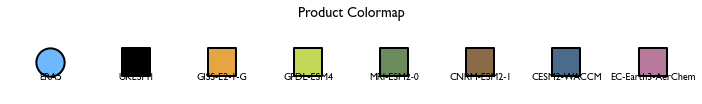

In [36]:

tcmap =  ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']
tcmap = krkonose_6 #prachovjezero_6
#tcmap = kostelec_6



products = {
    'ERA5': {'name': 'ERA5', 'color': '#6db8ff', 'marker': 'o'},
    'UKESM1-0-LL': {'name': 'UKESM1', 'color': 'k', 'marker': 's'},
    'GISS-E2-1-G': {'name': 'GISS-E2-1-G', 'color': tcmap[0], 'marker': 's'},
    'GFDL-ESM4': {'name': 'GFDL-ESM4', 'color': tcmap[1], 'marker': 's'},
    'MRI-ESM2-0': {'name': 'MRI-ESM2-0', 'color': tcmap[2], 'marker': 's'},
    'CNRM-ESM2-1': {'name': 'CNRM-ESM2-1', 'color': tcmap[5], 'marker': 's'},
    'CESM2-WACCM': {'name': 'CESM2-WACCM', 'color': tcmap[3], 'marker': 's'},
    'EC-Earth3-AerChem': {'name': 'EC-Earth3-AerChem', 'color': '#B87A9C', 'marker': 's'},
}

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each product as a dot
for i, (key, product) in enumerate(products.items()):
    ax.scatter(i, 0, s=800, color=product['color'], marker=product['marker'], 
               edgecolors='black', linewidth=2, zorder=3)
    ax.text(i, -0.2, product['name'], ha='center', fontsize=10, fontweight='bold')

# Customize plot
ax.set_xlim(-0.5, len(products) - 0.5)
ax.set_ylim(-0.4, 0.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Product Colormap', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()



### extract CMIP model ozone TS 70S-90S

    to get yearly bandmeans run
    
    (swamp2) [mep22dku@compute079 /gpfs/data/greenocean2/software/products/windsFromComponents/CMIP/o3/o3]$ python calc_bandmean70-90s.py

In [37]:


ex = False
if ex:
    
    tdir = '/gpfs/data/greenocean2/software/products/windsFromComponents/CMIP/o3/o3/'
    models = [
        "CESM2-WACCM", "CNRM-ESM2-1", "GFDL-ESM4",
        "GISS-E2-1-G", "MRI-ESM2-0", "UKESM1-0-LL"
    ]
    models = ['EC-Earth3-AerChem']
    for i, mod in enumerate(models):
        # Load all files for this model
        file_pattern = f'{tdir}/{mod}/historical/TCO_{mod}_*_90-70S_mean_TCO.nc'
        files = sorted(glob.glob(file_pattern))
        
        # Filter files to only include years <= 2019
        filtered_files = []
        for file in files:
            filename = Path(file).stem  # Get filename without extension
            # Extract year from filename
            parts = filename.split('_')
            
            # Try to find a 4-digit year in the filename
            for part in parts:
                if part.isdigit() and len(part) == 4:
                    year = int(part)
                    if year <= 2019:
                        filtered_files.append(file)
                    break
        
        print(f'{mod}: Found {len(files)} files total, {len(filtered_files)} files with year <= 2019')
        
        if not filtered_files:
            print(f'No files found for {mod} with year <= 2019, skipping')
            continue
        
        # Open and concatenate filtered files
        ds = xr.open_mfdataset(filtered_files, combine='nested', concat_dim='time')
        tdir1 = '/gpfs/home/mep22dku/scratch/windEval/CMIP6/data/'

        ds.to_netcdf(f'{tdir1}/{mod}_90-70S_mean_TCO_ts.nc')
        print(f'saved {mod}')

## postprocess windspeed for EC

In [38]:
ex = False
if ex:
    import xarray as xr
    import glob

    idir = '/gpfs/data/greenocean2/software/products/windsFromComponents/CMIP/output/EC-Earth3-AerChem/'  # adjust if files are elsewhere
    odir = '/gpfs/home/mep22dku/scratch/windEval/CMIP6/data/'

    files = sorted(glob.glob(f'{idir}wspdas_EC-Earth3-AerChem_*_40-60S_mean_wspd.nc'))

    # Filter to 1980-2019
    files = [f for f in files if any(str(yr) in f for yr in range(1980, 2020))]
    print(f'Found {len(files)} files')

    ds = xr.open_mfdataset(files, combine='by_coords')
    ds.to_netcdf(f'{odir}wspdas_EC-Earth3-AerChem_1980-2019_40-60S_mean_wspd.nc')
    print(f'Saved {odir}wspdas_EC-Earth3-AerChem_1980-2019_40-60S_mean_wspd.nc')

### helper fxn

In [39]:
# ============================================================================
# Helper functions
# ============================================================================

def calculate_trends(time_series):
    """Calculate linear trend using scipy.stats.linregress"""
    valid = ~np.isnan(time_series)
    if np.sum(valid) < 2:
        return np.nan, np.nan
    x = np.arange(len(time_series))[valid]
    y = time_series[valid]
    result = stats.linregress(x, y)
    return result.slope, result.pvalue

def load_era5_data():
    """Load ERA5 data"""
    w = xr.open_dataset('/gpfs/data/greenocean2/software/products/windsFromComponents/dailyStandard/intProc/ERA5_40-60S_mean_wspd_ts.nc')
    return w.wspd10m

def load_model_data(model, scenario):
    """Load model data and return (data, time_coord_name)"""
    print(model)

    if model == 'EC-Earth3-AerChem':
        w = xr.open_dataset('./data/wspdas_EC-Earth3-AerChem_1980-2019_40-60S_mean_wspd.nc')
    else:
        w = xr.open_dataset(f'./data/{model}_{scenario}_1950-2099_40-60S_mean_wspd.nc')
    
    return w.wspdas, 'time'

def resample_by_season(data, time_coord, season):
    """Resample data by season (DJF, JJA, SON or annual)"""
    #print(season)
    if season == 'annual':
        return data.resample(**{time_coord: '1Y'}).mean()
    elif season == 'DJF':
        months = data[time_coord].dt.month
        mask = (months == 12) | (months == 1) | (months == 2)
        return data.where(mask, drop=False).resample(**{time_coord: '1Y'}).mean()
    elif season == 'JJA':
        months = data[time_coord].dt.month
        mask = (months == 6) | (months == 7) | (months == 8)
        return data.where(mask, drop=False).resample(**{time_coord: '1Y'}).mean()
    elif season == 'SON':
        months = data[time_coord].dt.month
        mask = (months == 9) | (months == 10) | (months == 11)
        return data.where(mask, drop=False).resample(**{time_coord: '1Y'}).mean()
    elif season == 'MAM':
        months = data[time_coord].dt.month
        mask = (months == 3) | (months == 4) | (months == 5)
        return data.where(mask, drop=False).resample(**{time_coord: '1Y'}).mean()

def calculate_trend(data, time_coord, year_range):
    """Calculate linear trend for given year range"""
    mask = (data[time_coord].dt.year >= year_range[0]) & (data[time_coord].dt.year <= year_range[1])
    subset = data.where(mask, drop=True)
    
    if len(subset) < 2:
        return np.nan
    
    years = subset[time_coord].dt.year.values.astype(float)
    values = subset.values
    
    # Remove NaNs
    valid_idx = ~np.isnan(values)
    if np.sum(valid_idx) < 2:
        return np.nan
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(years[valid_idx], values[valid_idx])
    return slope * 10  # decadal trend

def load_sam_data(prod):
    """Load SAM data for a product"""
    ds = xr.open_dataset(f'{sam_tdir}{prod}-SAM.nc')
    var_name = 'SAM'
    return ds[var_name]

def load_ozone_data(model):
    """Load ozone data for a model"""
    ozone_file = f'{ozone_tdir}/{model}_90-70S_mean_TCO_ts.nc'
    ds = xr.open_dataset(ozone_file)
    ozone_var = list(ds.data_vars)[0]
    return ds[ozone_var]

def fix_360day_calendar(data, time_coord):
    """Convert 360-day calendar to standard datetime"""
    try:
        import cftime
        times = data[time_coord].values
        if isinstance(times[0], cftime.datetime):
            # Convert cftime to numpy datetime64
            data = data.assign_coords({time_coord: ('time_counter' if time_coord == 'time_counter' else 'time', 
                                                     [np.datetime64(t.isoformat()) for t in times])})
    except:
        pass
    return data

## load obs ozone

Text(0, 0.5, 'Total Column Ozone (DU)')

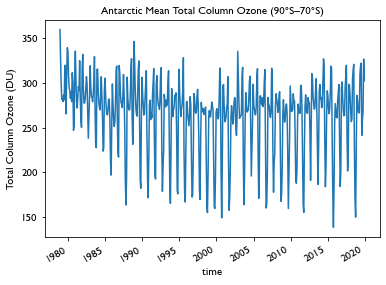

In [40]:
minlat = -90
maxlat = -70
 
ds = xr.open_dataset(
    '/gpfs/data/greenocean2/software/products/windsFromComponents/CMIP/o3/BSFilledTCO_V3.4.1_Monthly.nc'
)
 
tco = ds['tco'].sel(latitude=slice(minlat, maxlat))
 
weights = np.cos(np.deg2rad(tco.latitude))
antarctic_tco = tco.weighted(weights).mean(dim=['latitude', 'longitude'])
 
antarctic_tco.plot()
plt.title('Antarctic Mean Total Column Ozone (90°S–70°S)')
plt.ylabel('Total Column Ozone (DU)')

In [41]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

# 1. Load and Preprocess (using your provided logic)
ds = xr.open_dataset('/gpfs/data/greenocean2/software/products/windsFromComponents/CMIP/o3/BSFilledTCO_V3.4.1_Monthly.nc')
tco = ds['tco'].sel(latitude=slice(-90, -70))
weights = np.cos(np.deg2rad(tco.latitude))
antarctic_tco = tco.weighted(weights).mean(dim=['latitude', 'longitude'])

# 2. Define Resampling Functions
def get_seasonal_trend(data, start_year, end_year):
    """Calculates trends for Annual and all four seasons (DJF, MAM, JJA, SON)"""
    
    # Subset time
    subset = data.sel(time=slice(f'{start_year}-01-01', f'{end_year}-12-31'))
    
    # Create Averages
    annual = subset.resample(time='YS').mean()
    # 'QS-DEC' anchors quarters at December, creating: DJF, MAM, JJA, SON
    seasonal = subset.resample(time='QS-DEC').mean()
    
    # Extract each season by month
    djf = seasonal.sel(time=seasonal.time.dt.month == 12)  # DJF
    mam = seasonal.sel(time=seasonal.time.dt.month == 3)   # MAM
    jja = seasonal.sel(time=seasonal.time.dt.month == 6)   # JJA
    son = seasonal.sel(time=seasonal.time.dt.month == 9)   # SON
    
    datasets = {
        'Annual': annual,
        'Summer (DJF)': djf,
        'Autumn (MAM)': mam,
        'Winter (JJA)': jja,
        'Spring (SON)': son
    }
    
    print(f"--- Trends for {start_year}-{end_year} (DU/year) ---")
    
    for label, ds_vals in datasets.items():
        # Remove NaNs which can occur at the edges of seasonal resampling
        clean_ds = ds_vals.dropna(dim='time')
        
        # Convert time to decimal years for regression
        x = clean_ds.time.dt.year.values
        y = clean_ds.values
        
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        print(f"{label:15} | Trend: {slope:6.3f} | p-val: {p_value:6.4f} | R²: {r_value**2:5.3f}")
    print("\n")

# 3. Execute for requested periods
get_seasonal_trend(antarctic_tco, 1980, 1999)
get_seasonal_trend(antarctic_tco, 1980, 2019)

--- Trends for 1980-1999 (DU/year) ---
Annual          | Trend: -2.382 | p-val: 0.0000 | R²: 0.790
Summer (DJF)    | Trend: -1.622 | p-val: 0.0000 | R²: 0.691
Autumn (MAM)    | Trend: -0.779 | p-val: 0.0048 | R²: 0.365
Winter (JJA)    | Trend: -1.954 | p-val: 0.0001 | R²: 0.598
Spring (SON)    | Trend: -5.043 | p-val: 0.0000 | R²: 0.691


--- Trends for 1980-2019 (DU/year) ---
Annual          | Trend: -0.431 | p-val: 0.0190 | R²: 0.136
Summer (DJF)    | Trend: -0.368 | p-val: 0.0076 | R²: 0.169
Autumn (MAM)    | Trend: -0.100 | p-val: 0.3029 | R²: 0.028
Winter (JJA)    | Trend: -0.355 | p-val: 0.0498 | R²: 0.098
Spring (SON)    | Trend: -0.817 | p-val: 0.0834 | R²: 0.077




## S1: timeseries plot of ozone, sam winds

UKESM1-0-LL
GFDL-ESM4
MRI-ESM2-0
CNRM-ESM2-1
GISS-E2-1-G
EC-Earth3-AerChem


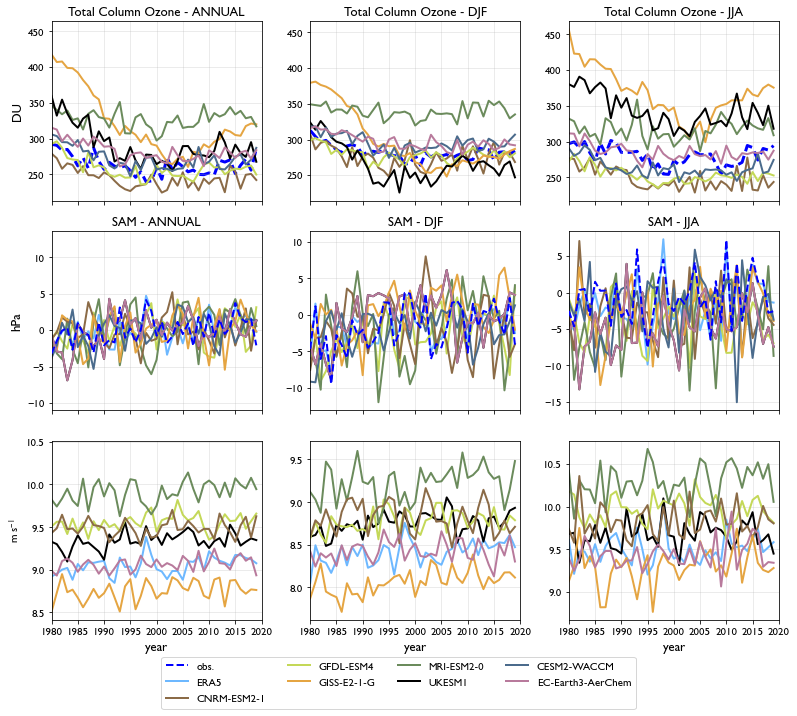

In [42]:
# ============================================================================
# Configuration
# ============================================================================

wind_tdir = '/gpfs/data/greenocean2/software/products/windsFromComponents/dailyStandard/intProc/'
ozone_tdir = '/gpfs/home/mep22dku/scratch/windEval/CMIP6/data/'
sam_tdir = '/gpfs/data/greenocean2/software/products/windsFromComponents/CMIP/psl/SAM-1980-2019/'

wind_models = ['UKESM1-0-LL', 'GFDL-ESM4', 'MRI-ESM2-0', 'CNRM-ESM2-1', 'GISS-E2-1-G', 'EC-Earth3-AerChem']
ozone_models = ["CNRM-ESM2-1", "GFDL-ESM4", "GISS-E2-1-G", "MRI-ESM2-0", "UKESM1-0-LL",'CESM2-WACCM','EC-Earth3-AerChem']
sam_models = ['obs', 'ERA5', 'UKESM1-0-LL', 'GFDL-ESM4', 'MRI-ESM2-0', 'CNRM-ESM2-1', 'GISS-E2-1-G', 'CESM2-WACCM','EC-Earth3-AerChem']

# ============================================================================
# Load satellite ozone data (Antarctic TCO)
# ============================================================================

minlat = -90
maxlat = -70

ds_sat = xr.open_dataset(
    '/gpfs/data/greenocean2/software/products/windsFromComponents/CMIP/o3/BSFilledTCO_V3.4.1_Monthly.nc'
)

tco = ds_sat['tco'].sel(latitude=slice(minlat, maxlat))
weights = np.cos(np.deg2rad(tco.latitude))
antarctic_tco = tco.weighted(weights).mean(dim=['latitude', 'longitude'])

# ============================================================================
# Load wind data (1980-2019)
# ============================================================================

seasons = ['annual', 'DJF', 'JJA']
year_range = (1980, 2019)
x_range = (1980, 2020)

wind_data = {}

# ERA5
era5_wind = load_era5_data()
wind_data['ERA5'] = {}
for season in seasons:
    seasonal = resample_by_season(era5_wind, 'time_counter', season)
    mask = (seasonal.time_counter.dt.year >= year_range[0]) & (seasonal.time_counter.dt.year <= year_range[1])
    wind_data['ERA5'][season] = seasonal.where(mask, drop=True)

# Wind models
for model in wind_models:
    model_wind, time_coord = load_model_data(model, 'ssp370')
    wind_data[model] = {}
    for season in seasons:
        seasonal = resample_by_season(model_wind, time_coord, season)
        mask = (seasonal[time_coord].dt.year >= year_range[0]) & (seasonal[time_coord].dt.year <= year_range[1])
        wind_data[model][season] = seasonal.where(mask, drop=True)

# ============================================================================
# Load SAM data (1980-2015)
# ============================================================================

sam_data = {}

for prod in sam_models:
    sam_ds = load_sam_data(prod)
    time_coord = list(sam_ds.dims)[0]
    
    sam_data[prod] = {}
    for season in seasons:
        seasonal = resample_by_season(sam_ds, time_coord, season)
        mask = (seasonal[time_coord].dt.year >= year_range[0]) & (seasonal[time_coord].dt.year <= year_range[1])
        sam_data[prod][season] = seasonal.where(mask, drop=True)

# ============================================================================
# Load ozone data (1980-2015)
# ============================================================================

ozone_data = {}

for model in ozone_models:
    ozone_file = f'{ozone_tdir}/{model}_90-70S_mean_TCO_ts.nc'
    ds = xr.open_dataset(ozone_file)
    ozone_var = list(ds.data_vars)[0]
    data = ds[ozone_var]
    time_coord = list(data.dims)[0]
    
    ozone_data[model] = {}
    for season in seasons:
        seasonal = resample_by_season(data, time_coord, season)
        mask = (seasonal[time_coord].dt.year >= year_range[0]) & (seasonal[time_coord].dt.year <= year_range[1])
        ozone_data[model][season] = seasonal.where(mask, drop=True)

# ============================================================================
# Helper function to calculate y range with consistent span
# ============================================================================

def get_y_ranges_with_consistent_span(data_by_season):
    """Get y ranges for each season with consistent span across all seasons"""
    spans = []
    mins = []
    
    for data_list in data_by_season:
        all_values = []
        for data in data_list:
            if data is not None:
                all_values.extend(data[~np.isnan(data)])
        if all_values:
            vmin, vmax = np.min(all_values), np.max(all_values)
            spans.append(vmax - vmin)
            mins.append(vmin)
    
    if spans:
        # Use the maximum span across all seasons as the reference
        reference_span = max(spans)
        ranges = []
        for i, vmin in enumerate(mins):
            y_min = vmin - 0.05 * reference_span
            y_max = vmin + reference_span + 0.05 * reference_span
            ranges.append((y_min, y_max))
        return ranges
    return [(0, 1), (0, 1), (0, 1)]

# ============================================================================
# Create combined plot (3 rows x 3 columns)
# ============================================================================

fact = 0.7
fig, axs = plt.subplots(3, 3, figsize=(16*fact, 14*fact), facecolor='w', sharex=True)

# ---- Top row: Ozone data (with satellite overlay) ----
# Calculate y ranges for ozone row (consistent span)
ozone_data_by_season = [[], [], []]
for ax_idx, season in enumerate(seasons):
    # Satellite
    if season == 'annual':
        sat_seasonal = antarctic_tco.resample(time='1Y').mean()
    elif season == 'DJF':
        months = antarctic_tco.time.dt.month
        mask = (months == 12) | (months == 1) | (months == 2)
        sat_seasonal = antarctic_tco.where(mask, drop=False).resample(time='1Y').mean()
    elif season == 'JJA':
        months = antarctic_tco.time.dt.month
        mask = (months == 6) | (months == 7) | (months == 8)
        sat_seasonal = antarctic_tco.where(mask, drop=False).resample(time='1Y').mean()
    
    mask_yrs = (sat_seasonal.time.dt.year >= year_range[0]) & (sat_seasonal.time.dt.year <= year_range[1])
    sat_subset = sat_seasonal.where(mask_yrs, drop=True)
    ozone_data_by_season[ax_idx].append(sat_subset.values)
    
    for model in ozone_models:
        if season in ozone_data[model]:
            ozone_data_by_season[ax_idx].append(ozone_data[model][season].values)

ozone_y_ranges = get_y_ranges_with_consistent_span(ozone_data_by_season)

for ax_idx, season in enumerate(seasons):
    ax = axs[0, ax_idx]
    
    # Satellite ozone (dotted blue line)
    if season == 'annual':
        sat_seasonal = antarctic_tco.resample(time='1Y').mean()
    elif season == 'DJF':
        months = antarctic_tco.time.dt.month
        mask = (months == 12) | (months == 1) | (months == 2)
        sat_seasonal = antarctic_tco.where(mask, drop=False).resample(time='1Y').mean()
    elif season == 'JJA':
        months = antarctic_tco.time.dt.month
        mask = (months == 6) | (months == 7) | (months == 8)
        sat_seasonal = antarctic_tco.where(mask, drop=False).resample(time='1Y').mean()
    
    mask_yrs = (sat_seasonal.time.dt.year >= year_range[0]) & (sat_seasonal.time.dt.year <= year_range[1])
    sat_subset = sat_seasonal.where(mask_yrs, drop=True)
    ax.plot(sat_subset.time.dt.year, sat_subset.values,
           color='blue', linewidth=3, linestyle='--', label='Satellite', zorder=0)
    
    # Models
    for model in ozone_models:
        if season in ozone_data[model]:
            data_subset = ozone_data[model][season]
            time_coord = list(data_subset.dims)[0]
            ax.plot(data_subset[time_coord].dt.year, data_subset.values,
                   color=products[model]['color'], linewidth=2, label=products[model]['name'])
    
    if ax_idx == 0:
        ax.set_ylabel('DU', fontsize=13, fontweight='bold')
    ax.set_title(f'Total Column Ozone - {season.upper()}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(x_range)
    ax.set_ylim(ozone_y_ranges[ax_idx])
    ax.tick_params(axis='x', labelsize=3)

# ---- Middle row: SAM data ----
# Calculate y ranges for SAM row (consistent span)
sam_data_by_season = [[], [], []]
for ax_idx, season in enumerate(seasons):
    if season in sam_data['obs']:
        data_subset = sam_data['obs'][season]
        sam_data_by_season[ax_idx].append(data_subset.values)
    
    for prod in sam_models:
        if prod != 'obs' and season in sam_data[prod]:
            sam_data_by_season[ax_idx].append(sam_data[prod][season].values)

sam_y_ranges = get_y_ranges_with_consistent_span(sam_data_by_season)

for ax_idx, season in enumerate(seasons):
    ax = axs[1, ax_idx]
    
    # Plot obs in blue with thick line
    if season in sam_data['obs']:
        data_subset = sam_data['obs'][season]
        time_coord = list(data_subset.dims)[0]
        ax.plot(data_subset[time_coord].dt.year, data_subset.values,
               color='blue', linewidth=2, linestyle='--', label='obs', zorder=10)
    
    # Model data (including ERA5)
    for prod in sam_models:
        if prod != 'obs' and season in sam_data[prod]:
            data_subset = sam_data[prod][season]
            time_coord = list(data_subset.dims)[0]
            ax.plot(data_subset[time_coord].dt.year, data_subset.values,
                   color=products[prod]['color'], linewidth=2, label=products[prod]['name'])
    
    if ax_idx == 0:
        ax.set_ylabel('hPa', fontsize=13, fontweight='bold')
    ax.set_title(f'SAM - {season.upper()}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(x_range)
    ax.set_ylim(sam_y_ranges[ax_idx])
    if ax_idx == 0:
        modrange = sam_y_ranges[ax_idx]#
        #print(modrange)#+ 3
        ofs = -3
        modrange = list(modrange)
        modrange[0] = modrange[0] + ofs
        modrange[1] = modrange[1] + ofs
        ax.set_ylim(modrange)
    ax.tick_params(axis='x', labelsize=3)

# ---- Bottom row: Wind data ----
# Calculate y ranges for wind row (consistent span)
wind_data_by_season = [[], [], []]
for ax_idx, season in enumerate(seasons):
    if season in wind_data['ERA5']:
        wind_data_by_season[ax_idx].append(wind_data['ERA5'][season].values)
    
    for model in wind_models:
        if season in wind_data[model]:
            wind_data_by_season[ax_idx].append(wind_data[model][season].values)

wind_y_ranges = get_y_ranges_with_consistent_span(wind_data_by_season)

for ax_idx, season in enumerate(seasons):
    ax = axs[2, ax_idx]
    
    # ERA5
    if season in wind_data['ERA5']:
        data_subset = wind_data['ERA5'][season]
        time_coord = list(data_subset.dims)[0]
        ax.plot(data_subset[time_coord].dt.year, data_subset.values,
               color=products['ERA5']['color'], linewidth=2, label='ERA5')
    
    # Models
    for model in wind_models:
        if season in wind_data[model]:
            data_subset = wind_data[model][season]
            time_coord = list(data_subset.dims)[0]
            ax.plot(data_subset[time_coord].dt.year, data_subset.values,
                   color=products[model]['color'], linewidth=2, label=products[model]['name'])
    
    ax.set_xlabel('year', fontsize=13, fontweight='bold')
    if ax_idx == 0:
        ax.set_ylabel('m s$^{-1}$')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(wind_y_ranges[ax_idx])
    
# # ============================================================================
# # Create single legend (no duplicates)
# # ============================================================================

handles = []
labels = []

# Observations (anything with -- linestyle)
handles.append(plt.Line2D([0], [0], color='blue', linestyle='--', linewidth=2))
labels.append('obs.')

# ERA5
handles.append(plt.Line2D([0], [0], color=products['ERA5']['color'], linewidth=2))
labels.append('ERA5')

# All unique models (combine ozone_models and wind_models, remove duplicates)
all_models = list(dict.fromkeys(ozone_models + wind_models))
for model in all_models:
    color = products[model]['color']
    handles.append(plt.Line2D([0], [0], color=color, linewidth=2))
    labels.append(products[model]['name'])

fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=11,
          bbox_to_anchor=(0.5, -0.02), frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])


plt.savefig('./plts-gill/S1-sam-wind-tco-TS.jpg', dpi=150, bbox_inches='tight')
plt.show()

## calculate trends in winds, sam, tco - add SON

In [43]:

# ============================================================================
# Configuration
# ============================================================================

wind_tdir = '/gpfs/data/greenocean2/software/products/windsFromComponents/dailyStandard/intProc/'
ozone_tdir = '/gpfs/home/mep22dku/scratch/windEval/CMIP6/data/'
sam_tdir = '/gpfs/data/greenocean2/software/products/windsFromComponents/CMIP/psl/SAM-1980-2019/'

wind_models = ['UKESM1-0-LL', 'GFDL-ESM4', 'MRI-ESM2-0', 'CNRM-ESM2-1', 'GISS-E2-1-G','EC-Earth3-AerChem']
ozone_models = ["CNRM-ESM2-1", "GFDL-ESM4", "GISS-E2-1-G", "MRI-ESM2-0", "UKESM1-0-LL",'EC-Earth3-AerChem']
sam_models = ['obs', 'ERA5', 'UKESM1-0-LL', 'GFDL-ESM4', 'MRI-ESM2-0', 'CNRM-ESM2-1', 'GISS-E2-1-G','EC-Earth3-AerChem']

# ============================================================================
# Calculate trends
# ============================================================================

seasons = ['annual', 'DJF', 'JJA','SON']
year_ranges = [(1980, 1999), (1980, 2019)]

# ---- SAM Trends ----
sam_trends = []

for prod in sam_models:
    sam_ds = load_sam_data(prod)
    time_coord = list(sam_ds.dims)[0]
    
    for season in seasons:
        #print(season)
        seasonal = resample_by_season(sam_ds, time_coord, season)
        
        
        for year_range in year_ranges:
            trend = calculate_trend(seasonal, time_coord, year_range)
            sam_trends.append({
                'Model': prod,
                'Season': season,
                'Period': f'{year_range[0]}-{year_range[1]}',
                'Trend': trend,
                'Variable': 'SAM'
            })

sam_df = pd.DataFrame(sam_trends)

# ---- Wind Trends ----
wind_trends = []

# ERA5
era5_wind = load_era5_data()
for season in seasons:
    seasonal = resample_by_season(era5_wind, 'time_counter', season)
    
    for year_range in year_ranges:
        trend = calculate_trend(seasonal, 'time_counter', year_range)
        wind_trends.append({
            'Model': 'ERA5',
            'Season': season,
            'Period': f'{year_range[0]}-{year_range[1]}',
            'Trend': trend,
            'Variable': 'Wind'
        })

# Wind models
for model in wind_models:
    model_wind, time_coord = load_model_data(model, 'ssp370')
    
    for season in seasons:
        seasonal = resample_by_season(model_wind, time_coord, season)
        
        for year_range in year_ranges:
            trend = calculate_trend(seasonal, time_coord, year_range)
            wind_trends.append({
                'Model': model,
                'Season': season,
                'Period': f'{year_range[0]}-{year_range[1]}',
                'Trend': trend,
                'Variable': 'Wind'
            })

wind_df = pd.DataFrame(wind_trends)

# ---- Ozone (TCO) Trends ----
tco_trends = []

for model in ozone_models:
    data = load_ozone_data(model)
    time_coord = list(data.dims)[0]
    
    for season in seasons:
        seasonal = resample_by_season(data, time_coord, season)
        
        # 1980-1999 trend
        trend_1980s = calculate_trend(seasonal, time_coord, (1980, 1999))
        tco_trends.append({
            'Model': model,
            'Season': season,
            'Period': '1980-1999',
            'Trend': trend_1980s,
            'Variable': 'TCO'
        })
        
        # 1980-2019 trend - set to NaN since ozone data only goes to 2014
        trend_full = calculate_trend(seasonal, time_coord, (1980, 2019))
        tco_trends.append({
            'Model': model,
            'Season': season,
            'Period': '1980-2019',
            'Trend': trend_full,
            'Variable': 'TCO'
        })

tco_df = pd.DataFrame(tco_trends)



UKESM1-0-LL
GFDL-ESM4
MRI-ESM2-0
CNRM-ESM2-1
GISS-E2-1-G
EC-Earth3-AerChem


## display results (if toggled)

In [44]:
show = True

if show:

    # ============================================================================
    # Display and save results
    # ============================================================================

    print("\n" + "="*80)
    print("SAM TRENDS")
    print("="*80)
    print(sam_df.to_string(index=False))
    sam_df.to_csv('./trends/SAM_trends_1980-2019.csv', index=False)

    print("\n" + "="*80)
    print("WIND TRENDS")
    print("="*80)
    print(wind_df.to_string(index=False))
    wind_df.to_csv('./trends/Wind_trends_1980-2019.csv', index=False)

    print("\n" + "="*80)
    print("TCO TRENDS")
    print("="*80)
    print(tco_df.to_string(index=False))
    tco_df.to_csv('./trends/TCO_trends_1980-2019_wson.csv', index=False)

    # ============================================================================
    # Summary tables (pivot format)
    # ============================================================================

    print("\n" + "="*80)
    print("SUMMARY: SAM TRENDS BY SEASON AND PERIOD")
    print("="*80)
    sam_pivot = sam_df.pivot_table(index='Model', columns=['Season', 'Period'], values='Trend')
    print(sam_pivot)

    print("\n" + "="*80)
    print("SUMMARY: WIND TRENDS BY SEASON AND PERIOD")
    print("="*80)
    wind_pivot = wind_df.pivot_table(index='Model', columns=['Season', 'Period'], values='Trend')
    print(wind_pivot)

    print("\n" + "="*80)
    print("SUMMARY: TCO TRENDS BY SEASON AND PERIOD")
    print("="*80)
    tco_pivot = tco_df.pivot_table(index='Model', columns=['Season', 'Period'], values='Trend')
    print(tco_pivot)


SAM TRENDS
            Model Season    Period     Trend Variable
              obs annual 1980-1999  1.636059      SAM
              obs annual 1980-2019  0.547384      SAM
              obs    DJF 1980-1999  2.931353      SAM
              obs    DJF 1980-2019  1.001601      SAM
              obs    JJA 1980-1999  0.522657      SAM
              obs    JJA 1980-2019  0.469046      SAM
              obs    SON 1980-1999  0.179373      SAM
              obs    SON 1980-2019 -0.087830      SAM
             ERA5 annual 1980-1999  1.470678      SAM
             ERA5 annual 1980-2019  0.598824      SAM
             ERA5    DJF 1980-1999  2.700948      SAM
             ERA5    DJF 1980-2019  0.919548      SAM
             ERA5    JJA 1980-1999  0.711753      SAM
             ERA5    JJA 1980-2019  0.568144      SAM
             ERA5    SON 1980-1999  0.534314      SAM
             ERA5    SON 1980-2019  0.100825      SAM
      UKESM1-0-LL annual 1980-1999  2.808241      SAM
      UKESM1-0-L

In [45]:
tco_df.to_csv('./trends/TCO_trends_1980-2019_wson.csv')

## S3: SAM-wind scatter

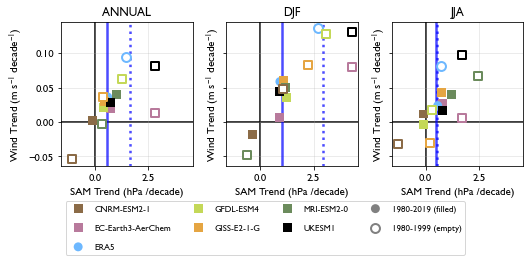

In [46]:
seasons = ['annual', 'DJF', 'JJA']
ms = 8  # marker size scale
ty = 7
fact = 0.5
# ============================================================================
# Load data from CSVs
# ============================================================================

sam_df = pd.read_csv('./trends/SAM_trends_1980-2019.csv')
wind_df = pd.read_csv('./trends/Wind_trends_1980-2019.csv')
tco_df = pd.read_csv('./trends/TCO_trends_1980-2019_wson.csv')

# ---- Pivot to make easier to work with ----

# SAM trends
sam_full = sam_df[sam_df['Period'] == '1980-2019'].pivot_table(index='Season', columns='Model', values='Trend')
sam_1980s = sam_df[sam_df['Period'] == '1980-1999'].pivot_table(index='Season', columns='Model', values='Trend')

# Wind trends
wind_full = wind_df[wind_df['Period'] == '1980-2019'].pivot_table(index='Season', columns='Model', values='Trend')
wind_1980s = wind_df[wind_df['Period'] == '1980-1999'].pivot_table(index='Season', columns='Model', values='Trend')

# TCO trends
tco_full = tco_df[tco_df['Period'] == '1980-2019'].pivot_table(index='Season', columns='Model', values='Trend')
tco_1980s = tco_df[tco_df['Period'] == '1980-1999'].pivot_table(index='Season', columns='Model', values='Trend')

# Get list of models to plot for each dataset
sam_models = [m for m in sam_full.columns if m in products]
wind_models = [m for m in wind_full.columns if m in products]
tco_models = [m for m in tco_1980s.columns if m in products]

# ============================================================================
# SAM vs Wind Scatter
# ============================================================================

fig, axs = plt.subplots(1, 3, figsize=(15*fact, ty*fact), facecolor='w', sharex=True, sharey=True)
axs = axs.ravel()

for ax_idx, season in enumerate(seasons):
    ax = axs[ax_idx]
    
    # Plot full period (filled symbols)
    for model in wind_models:
        if model in sam_full.columns and model in wind_full.columns:
            sam_val = sam_full.loc[season, model]
            wind_val = wind_full.loc[season, model]
            
            color = products[model]['color']
            marker = products[model]['marker']
            
            ax.scatter(sam_val, wind_val, c=color, marker=marker, s=ms*10,
                      edgecolors='none', zorder=3)
    
    # Plot 1980-1999 period (open symbols)
    for model in wind_models:
        if model in sam_1980s.columns and model in wind_1980s.columns:
            sam_val = sam_1980s.loc[season, model]
            wind_val = wind_1980s.loc[season, model]
            
            color = products[model]['color']
            marker = products[model]['marker']
            
            ax.scatter(sam_val, wind_val, c='white', marker=marker, s=ms*10,
                      edgecolors=color, linewidth=2, zorder=3)
    
    # Add obs lines if available
    if 'obs' in sam_full.columns and not pd.isna(sam_full.loc[season, 'obs']):
        obs_sam = sam_full.loc[season, 'obs']
        ax.axvline(x=obs_sam, color='blue', linestyle='-', linewidth=2.5, 
                  alpha=0.7, zorder=2)
    
    if 'obs' in sam_1980s.columns and not pd.isna(sam_1980s.loc[season, 'obs']):
        obs_sam80 = sam_1980s.loc[season, 'obs']
        ax.axvline(x=obs_sam80, color='blue', linestyle=':', linewidth=2.5, 
                  alpha=0.7, zorder=2)
    
    ax.set_xlabel('SAM Trend (hPa /decade)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Wind Trend (m s$^{-1}$ decade$^{-1}$)', fontsize=11, fontweight='bold')
    ax.set_title(f'{season.upper()}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=0)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# Add legend
handles_legend = []
labels_legend = []
for model in wind_models:
    if model in products:
        color = products[model]['color']
        marker = products[model]['marker']
        handles_legend.append(plt.scatter([], [], c=color, marker=marker, s=ms*10, edgecolors='none'))
        labels_legend.append(products[model]['name'])

handles_legend.append(plt.scatter([], [], c='gray', marker='o', s=80, edgecolors='none'))
labels_legend.append('1980-2019 (filled)')
handles_legend.append(plt.scatter([], [], c='white', marker='o', s=80, edgecolors='gray', linewidth=2))
labels_legend.append('1980-1999 (empty)')

fig.legend(handles_legend, labels_legend, loc='lower center', fontsize=9,
          bbox_to_anchor=(0.5, -0.05), frameon=True, ncol=4, 
          labelspacing=1.2, handletextpad=0.8)
plt.tight_layout(rect=[0, 0.15, 1, 1])
plt.savefig('./plts-gill/S3-sam-wind-scatter.jpg', dpi=150, bbox_inches='tight')
plt.show()



## MAIN FIGURE: combined means v trends and TCO v trends figure 

UKESM1-0-LL
GFDL-ESM4
MRI-ESM2-0
CNRM-ESM2-1
GISS-E2-1-G
EC-Earth3-AerChem


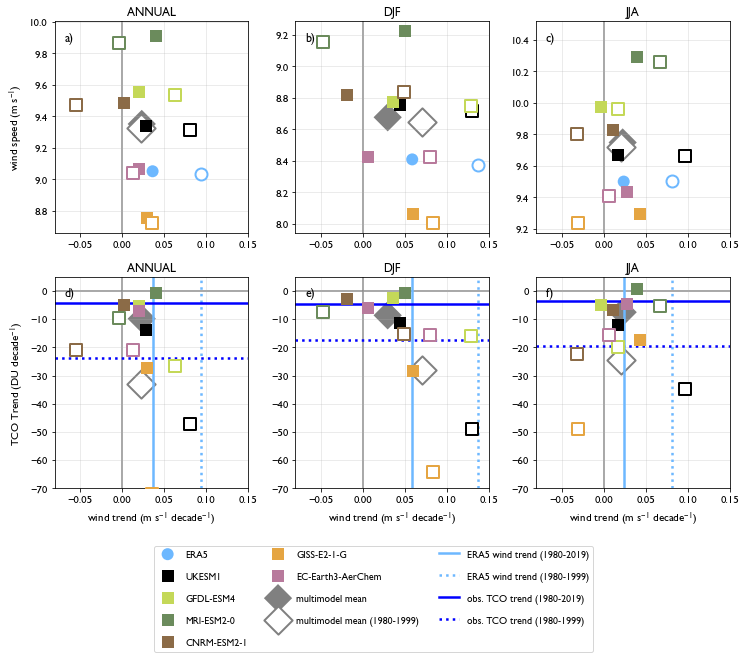

In [47]:
mmean = True

# ============================================================================
# Configuration
# ============================================================================

model_list = ['UKESM1-0-LL', 'GFDL-ESM4', \
              'MRI-ESM2-0', 'CNRM-ESM2-1', 'GISS-E2-1-G', 'EC-Earth3-AerChem']

# ============================================================================
# Load satellite ozone data
# ============================================================================

minlat = -90
maxlat = -70
ds_sat = xr.open_dataset(
    '/gpfs/data/greenocean2/software/products/windsFromComponents/CMIP/o3/BSFilledTCO_V3.4.1_Monthly.nc'
)
tco = ds_sat['tco'].sel(latitude=slice(minlat, maxlat))
weights = np.cos(np.deg2rad(tco.latitude))
antarctic_tco = tco.weighted(weights).mean(dim=['latitude', 'longitude'])

# ============================================================================
# Load and process wind data
# ============================================================================

seasons = ['annual', 'DJF', 'JJA']
periods = {
    '1980-2019': (1980, 2019),
    '1980-1999': (1980, 1999)
}

# Store results: {season: {period: {model: (mean, trend)}}}
wind_results = {season: {period: {} for period in periods} for season in seasons}

# ERA5
era5_data = load_era5_data()
for season in seasons:
    era5_seasonal = resample_by_season(era5_data, 'time_counter', season)
    for period_name, (year_start, year_end) in periods.items():
        mask = (era5_seasonal.time_counter.dt.year >= year_start) & (era5_seasonal.time_counter.dt.year <= year_end)
        data_slice = era5_seasonal.where(mask, drop=True).values
        mean_val = np.nanmean(data_slice)
        trend, _ = calculate_trends(data_slice)
        wind_results[season][period_name]['ERA5'] = (mean_val, trend)

# Models
for model in model_list:
    scenario = 'ssp370'
    model_data, time_coord = load_model_data(model, scenario)
    
    for season in seasons:
        model_seasonal = resample_by_season(model_data, time_coord, season)
        for period_name, (year_start, year_end) in periods.items():
            mask = (model_seasonal[time_coord].dt.year >= year_start) & (model_seasonal[time_coord].dt.year <= year_end)
            data_slice = model_seasonal.where(mask, drop=True).values
            mean_val = np.nanmean(data_slice)
            trend, _ = calculate_trends(data_slice)
            wind_results[season][period_name][model] = (mean_val, trend)

# ============================================================================
# Calculate TCO trends
# ============================================================================

tco_results = {season: {period: None for period in periods} for season in seasons}

for season in seasons:
    # Resample by season
    if season == 'annual':
        tco_seasonal = antarctic_tco.resample(time='1Y').mean()
    elif season == 'DJF':
        months = antarctic_tco.time.dt.month
        mask = (months == 12) | (months == 1) | (months == 2)
        tco_seasonal = antarctic_tco.where(mask, drop=False).resample(time='1Y').mean()
    elif season == 'JJA':
        months = antarctic_tco.time.dt.month
        mask = (months == 6) | (months == 7) | (months == 8)
        tco_seasonal = antarctic_tco.where(mask, drop=False).resample(time='1Y').mean()
    
    # Calculate trends for each period
    for period_name, (year_start, year_end) in periods.items():
        mask = (tco_seasonal.time.dt.year >= year_start) & (tco_seasonal.time.dt.year <= year_end)
        data_slice = tco_seasonal.where(mask, drop=True).values
        
        if len(data_slice[~np.isnan(data_slice)]) >= 2:
            years = np.arange(year_start, year_end + 1)
            valid_idx = ~np.isnan(data_slice)
            slope, intercept, r_value, p_value, std_err = stats.linregress(years[valid_idx], data_slice[valid_idx])
            tco_results[season][period_name] = slope * 10  # decadal trend

# ============================================================================
# Create combined scatter plots
# ============================================================================

fact = 0.7
ms = 12
msm = 20  # size for multimodel mean markers

# ============================================================================
# Helper function for consistent y-axis span
# ============================================================================

def get_y_ranges_with_consistent_span(data_by_season):
    """Get y ranges for each season with consistent span across all seasons"""
    spans = []
    mins = []
    
    for data_list in data_by_season:
        all_values = []
        for data in data_list:
            if data is not None:
                all_values.extend(data[~np.isnan(data)])
        if all_values:
            vmin, vmax = np.min(all_values), np.max(all_values)
            spans.append(vmax - vmin)
            mins.append(vmin)
    
    if spans:
        # Use the maximum span across all seasons as the reference
        reference_span = max(spans)
        ranges = []
        for i, vmin in enumerate(mins):
            y_min = vmin - 0.05 * reference_span
            y_max = vmin + reference_span + 0.05 * reference_span
            ranges.append((y_min, y_max))
        return ranges
    return [(0, 1), (0, 1), (0, 1)]

# Axis limits (editable)
wind_trend_lim = (-0.08, 0.15)  # x-axis limits for wind trend
mean_wind_lim = (7.8, 10.2)     # y-axis limits for mean wind speed
tco_lim = (-70, 5)              # y-axis limits for TCO

fig, axs = plt.subplots(2, 3, figsize=(15*fact, 12*fact), facecolor='w')

# Subplot labels
subplot_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']
label_idx = 0

# Top row: Mean wind speed vs wind speed trend
for ax_idx, season in enumerate(seasons):
    ax = axs[0, ax_idx]
    
    # Collect wind speed data for y-range calculation
    wind_speed_data = []
    for model in ['ERA5'] + model_list:
        if model in wind_results[season]['1980-2019']:
            mean_val, trend = wind_results[season]['1980-2019'][model]
            wind_speed_data.append(mean_val)
        if model in wind_results[season]['1980-1999']:
            mean_val, trend = wind_results[season]['1980-1999'][model]
            wind_speed_data.append(mean_val)
    
    # Calculate y-ranges for consistent span across seasons
    if ax_idx == 0:
        # Collect all wind speed data for all seasons to calculate spans
        all_seasons_wind_data = []
        for s in seasons:
            season_data = []
            for model in ['ERA5'] + model_list:
                if model in wind_results[s]['1980-2019']:
                    mean_val, trend = wind_results[s]['1980-2019'][model]
                    season_data.append(mean_val)
                if model in wind_results[s]['1980-1999']:
                    mean_val, trend = wind_results[s]['1980-1999'][model]
                    season_data.append(mean_val)
            all_seasons_wind_data.append(season_data)
        wind_y_ranges = get_y_ranges_with_consistent_span(all_seasons_wind_data)
    
    # Plot 1980-2019 (filled symbols)
    for model in ['ERA5'] + model_list:
        if model in wind_results[season]['1980-2019']:
            mean_val, trend = wind_results[season]['1980-2019'][model]
            trend *= 10  # Convert to decadal trend
            color = products[model]['color']
            marker = products[model]['marker']
            
            ax.scatter(trend, mean_val, c=color, marker=marker, s=ms**2,
                      label=products[model]['name'], edgecolors='none', zorder=3)
    
    # Calculate and plot multimodel mean for 1980-2019 (filled diamond)
    mean_trends = []
    mean_values = []
    for model in model_list:
        if model in wind_results[season]['1980-2019']:
            mean_val, trend = wind_results[season]['1980-2019'][model]
            mean_trends.append(trend * 10)
            mean_values.append(mean_val)
    if mean_trends:
        mm_trend = np.mean(mean_trends)
        mm_value = np.mean(mean_values)
        if mmean:
            ax.scatter(mm_trend, mm_value, c='gray', marker='D', s=msm**2,
                      edgecolors='none', zorder=0, label='Multimodel mean')
    
    # Plot 1980-1999 (non-filled symbols)
    for model in ['ERA5'] + model_list:
        if model in wind_results[season]['1980-1999']:
            mean_val, trend = wind_results[season]['1980-1999'][model]
            trend *= 10
            color = products[model]['color']
            marker = products[model]['marker']
            
            ax.scatter(trend, mean_val, c='white', marker=marker, s=ms**2,
                      edgecolors=color, linewidth=2, zorder=3)
    
    # Calculate and plot multimodel mean for 1980-1999 (empty diamond)
    mean_trends_1999 = []
    mean_values_1999 = []
    for model in model_list:
        if model in wind_results[season]['1980-1999']:
            mean_val, trend = wind_results[season]['1980-1999'][model]
            mean_trends_1999.append(trend * 10)
            mean_values_1999.append(mean_val)
    if mean_trends_1999:
        mm_trend_1999 = np.mean(mean_trends_1999)
        mm_value_1999 = np.mean(mean_values_1999)
        if mmean:
            ax.scatter(mm_trend_1999, mm_value_1999, c='w', marker='D', s=msm**2,
                      edgecolors='gray', linewidth=2, zorder=0)
    
    if ax_idx == 0:
        ax.set_ylabel('wind speed (m s$^{-1}$)', fontsize=11, fontweight='bold')
    ax.set_title(f'{season.upper()}', fontsize=12, fontweight='bold')
    ax.text(0.05, 0.95, subplot_labels[label_idx], transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top')
    label_idx += 1
    ax.set_xlim(wind_trend_lim)
    ax.set_ylim(wind_y_ranges[ax_idx])
    ax.grid(True, alpha=0.3, zorder=0)
    ax.axvline(x=0, color='grey', linestyle='-', linewidth=1.5, alpha=0.9, zorder=1)

# Bottom row: TCO vs wind speed trend with ERA5 and satellite lines
for ax_idx, season in enumerate(seasons):
    ax = axs[1, ax_idx]
    
    # Plot ERA5 wind trends as vertical lines
    if season in wind_results:
        # Full period line (1980-2019)
        _, trend_full = wind_results[season]['1980-2019']['ERA5']
        trend_full *= 10
        
        # 1980-1999 period line
        _, trend_1999 = wind_results[season]['1980-1999']['ERA5']
        trend_1999 *= 10
        
        era5_color = products['ERA5']['color']
        
        # Draw full period line
        ax.axvline(x=trend_full, color=era5_color, linestyle='-', linewidth=2.5, 
                   label='ERA5 (1980-2019)', zorder=2)
        
        # Draw 1980-1999 line
        ax.axvline(x=trend_1999, color=era5_color, linestyle=':', linewidth=2.5, 
                   label='ERA5 (1980-1999)', zorder=2)
    
    # Plot TCO satellite trends as horizontal blue lines
    if season in tco_results:
        tco_trend_full = tco_results[season]['1980-2019']
        tco_trend_1999 = tco_results[season]['1980-1999']
        
        if tco_trend_full is not None:
            ax.axhline(y=tco_trend_full, color='blue', linestyle='-', linewidth=2.5, 
                       label='Satellite TCO (1980-2019)', zorder=2)
        
        if tco_trend_1999 is not None:
            ax.axhline(y=tco_trend_1999, color='blue', linestyle=':', linewidth=2.5, 
                       label='Satellite TCO (1980-1999)', zorder=2)
    
    # Plot model scatter points (from TCO data)
    for model in model_list:
        if model in tco_full.columns and model in wind_full.columns:
            tco_val = tco_full.loc[season, model]
            wind_val = wind_full.loc[season, model]
            
            if pd.isna(tco_val) or pd.isna(wind_val):
                continue
            
            color = products[model]['color']
            marker = products[model]['marker']
            
            ax.scatter(wind_val, tco_val, c=color, marker=marker, s=ms**2,
                      edgecolors='none', zorder=3)
    
    # Plot 1980-1999 period (open symbols)
    for model in model_list:
        if model in tco_1980s.columns and model in wind_1980s.columns:
            tco_val = tco_1980s.loc[season, model]
            wind_val = wind_1980s.loc[season, model]
            
            if pd.isna(tco_val) or pd.isna(wind_val):
                continue
            
            color = products[model]['color']
            marker = products[model]['marker']
            
            ax.scatter(wind_val, tco_val, c='white', marker=marker, s=ms**2,
                      edgecolors=color, linewidth=2, zorder=3)
    
    # Calculate and plot multimodel mean for 1980-2019 (filled diamond)
    mm_wind_trends = []
    mm_tco_trends = []
    for model in model_list:
        if model in tco_full.columns and model in wind_full.columns:
            tco_val = tco_full.loc[season, model]
            wind_val = wind_full.loc[season, model]
            if not pd.isna(tco_val) and not pd.isna(wind_val):
                mm_tco_trends.append(tco_val)
                mm_wind_trends.append(wind_val)
    
    if mm_wind_trends and mm_tco_trends:
        mm_wind = np.mean(mm_wind_trends)
        mm_tco = np.mean(mm_tco_trends)
        if mmean:
            ax.scatter(mm_wind, mm_tco, c='gray', marker='D', s=msm**2,
                      edgecolors='none', zorder=0)
    
    # Calculate and plot multimodel mean for 1980-1999 (empty diamond)
    mm_wind_trends_1999 = []
    mm_tco_trends_1999 = []
    for model in model_list:
        if model in tco_1980s.columns and model in wind_1980s.columns:
            tco_val = tco_1980s.loc[season, model]
            wind_val = wind_1980s.loc[season, model]
            if not pd.isna(tco_val) and not pd.isna(wind_val):
                mm_tco_trends_1999.append(tco_val)
                mm_wind_trends_1999.append(wind_val)
    
    if mm_wind_trends_1999 and mm_tco_trends_1999:
        mm_wind_1999 = np.mean(mm_wind_trends_1999)
        mm_tco_1999 = np.mean(mm_tco_trends_1999)
        if mmean:
            ax.scatter(mm_wind_1999, mm_tco_1999, c='white', marker='D', s=msm**2,
                      edgecolors='gray', linewidth=2, zorder=0)
    
    ax.set_xlabel('wind trend (m s$^{-1}$ decade$^{-1}$)', fontsize=11, fontweight='bold')
    if ax_idx == 0:
        ax.set_ylabel('TCO Trend (DU decade$^{-1}$)', fontsize=11, fontweight='bold')
    ax.set_title(f'{season.upper()}', fontsize=12, fontweight='bold')
    ax.text(0.05, 0.95, subplot_labels[label_idx], transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top')
    label_idx += 1
    ax.grid(True, alpha=0.3, zorder=0)
    ax.axhline(y=0, color='grey', linestyle='-', linewidth=1.5, alpha=0.9, zorder=1)
    ax.axvline(x=0, color='grey', linestyle='-', linewidth=1.5, alpha=0.9, zorder=1)
    ax.set_xlim(wind_trend_lim)
    ax.set_ylim(tco_lim)

# Add single legend at the bottom
handles = []
labels = []
for model in ['ERA5'] + model_list:
    color = products[model]['color']
    marker = products[model]['marker']
    handles.append(plt.scatter([], [], c=color, marker=marker, s=ms**2, edgecolors='none'))
    labels.append(products[model]['name'])

if mmean:
    handles.append(plt.scatter([], [], c='gray', marker='D', s=msm**2, edgecolors='none'))
    labels.append('multimodel mean')
if mmean:
    handles.append(plt.scatter([], [], c='white', marker='D', s=msm**2, edgecolors='gray', linewidth=2))
    labels.append('multimodel mean (1980-1999)')
    
# Add ERA5 and satellite TCO lines
handles.append(plt.Line2D([0], [0], color=products['ERA5']['color'], linestyle='-', linewidth=2.5))
labels.append('ERA5 wind trend (1980-2019)')
handles.append(plt.Line2D([0], [0], color=products['ERA5']['color'], linestyle=':', linewidth=2.5))
labels.append('ERA5 wind trend (1980-1999)')
handles.append(plt.Line2D([0], [0], color='blue', linestyle='-', linewidth=2.5))
labels.append('obs. TCO trend (1980-2019)')
handles.append(plt.Line2D([0], [0], color='blue', linestyle=':', linewidth=2.5))
labels.append('obs. TCO trend (1980-1999)')


fig.legend(handles, labels, loc='lower center', fontsize=10, 
          bbox_to_anchor=(0.5, -0.095), frameon=True, ncol=3, 
          labelspacing=1.2, handletextpad=0.8)

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig('./plts-gill/wind-tco-combined.jpg', dpi=150, bbox_inches='tight')
plt.show()

## S2: DJF and SON

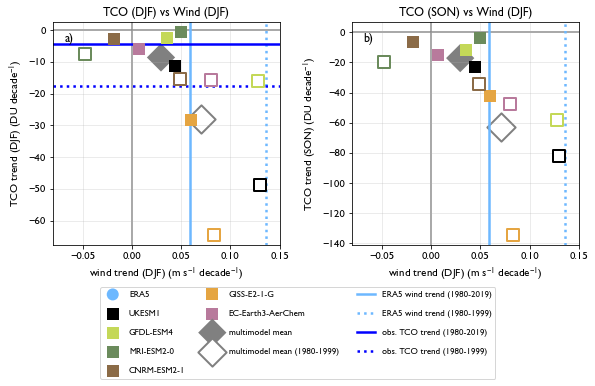

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Configuration
fact = 0.7
ms = 12
msm = 20  # size for multimodel mean markers
mmean = True

model_list = ['UKESM1-0-LL', 'GFDL-ESM4', 'MRI-ESM2-0', 'CNRM-ESM2-1', 'GISS-E2-1-G','EC-Earth3-AerChem']

# Define your products dictionary with colors and markers
# (you'll need to fill this with your actual color/marker definitions)
# products = {
#     'ERA5': {'color': 'black', 'marker': 'o', 'name': 'ERA5'},
#     'UKESM1-0-LL': {'color': 'red', 'marker': 's', 'name': 'UKESM1-0-LL'},
#     'GFDL-ESM4': {'color': 'blue', 'marker': '^', 'name': 'GFDL-ESM4'},
#     'MRI-ESM2-0': {'color': 'green', 'marker': 'v', 'name': 'MRI-ESM2-0'},
#     'CNRM-ESM2-1': {'color': 'orange', 'marker': 'D', 'name': 'CNRM-ESM2-1'},
#     'GISS-E2-1-G': {'color': 'purple', 'marker': 'p', 'name': 'GISS-E2-1-G'}
# }

# Axis limits
wind_trend_lim = (-0.08, 0.15)
tco_lim = (-140, 5)

fig, axs = plt.subplots(1, 2, figsize=(12*fact, 7*fact), facecolor='w')

subplot_labels = ['a)', 'b)']
wind_season = 'DJF'  # x-axis always DJF
tco_seasons = ['DJF', 'SON']  # y-axis TCO seasons

for ax_idx, tco_season in enumerate(tco_seasons):
    ax = axs[ax_idx]
    
    # Plot ERA5 wind trends as vertical lines
    if wind_season in wind_results:
        # Full period line (1980-2019)
        _, trend_full = wind_results[wind_season]['1980-2019']['ERA5']
        trend_full *= 10
        
        # 1980-1999 period line
        _, trend_1999 = wind_results[wind_season]['1980-1999']['ERA5']
        trend_1999 *= 10
        
        era5_color = products['ERA5']['color']
        
        # Draw full period line
        ax.axvline(x=trend_full, color=era5_color, linestyle='-', linewidth=2.5, 
                   label='ERA5 (1980-2019)', zorder=2)
        
        # Draw 1980-1999 line
        ax.axvline(x=trend_1999, color=era5_color, linestyle=':', linewidth=2.5, 
                   label='ERA5 (1980-1999)', zorder=2)
    
    # Plot TCO satellite trends as horizontal blue lines
    if tco_season in tco_results:
        tco_trend_full = tco_results[tco_season]['1980-2019']
        tco_trend_1999 = tco_results[tco_season]['1980-1999']
        
        if tco_trend_full is not None:
            ax.axhline(y=tco_trend_full, color='blue', linestyle='-', linewidth=2.5, 
                       label='Satellite TCO (1980-2019)', zorder=2)
        
        if tco_trend_1999 is not None:
            ax.axhline(y=tco_trend_1999, color='blue', linestyle=':', linewidth=2.5, 
                       label='Satellite TCO (1980-1999)', zorder=2)
    
    # Plot model scatter points (1980-2019, filled symbols)
    for model in model_list:
        if model in tco_full.columns and model in wind_full.columns:
            tco_val = tco_full.loc[tco_season, model]
            wind_val = wind_full.loc[wind_season, model]
            
            if pd.isna(tco_val) or pd.isna(wind_val):
                continue
            
            color = products[model]['color']
            marker = products[model]['marker']
            
            ax.scatter(wind_val, tco_val, c=color, marker=marker, s=ms**2,
                      edgecolors='none', zorder=3)
    
    # Plot 1980-1999 period (open symbols)
    for model in model_list:
        if model in tco_1980s.columns and model in wind_1980s.columns:
            tco_val = tco_1980s.loc[tco_season, model]
            wind_val = wind_1980s.loc[wind_season, model]
            
            if pd.isna(tco_val) or pd.isna(wind_val):
                continue
            
            color = products[model]['color']
            marker = products[model]['marker']
            
            ax.scatter(wind_val, tco_val, c='white', marker=marker, s=ms**2,
                      edgecolors=color, linewidth=2, zorder=3)
    
    # Calculate and plot multimodel mean for 1980-2019 (filled diamond)
    mm_wind_trends = []
    mm_tco_trends = []
    for model in model_list:
        if model in tco_full.columns and model in wind_full.columns:
            tco_val = tco_full.loc[tco_season, model]
            wind_val = wind_full.loc[wind_season, model]
            if not pd.isna(tco_val) and not pd.isna(wind_val):
                mm_tco_trends.append(tco_val)
                mm_wind_trends.append(wind_val)
    
    if mm_wind_trends and mm_tco_trends:
        mm_wind = np.mean(mm_wind_trends)
        mm_tco = np.mean(mm_tco_trends)
        if mmean:
            ax.scatter(mm_wind, mm_tco, c='gray', marker='D', s=msm**2,
                      edgecolors='none', zorder=0)
    
    # Calculate and plot multimodel mean for 1980-1999 (empty diamond)
    mm_wind_trends_1999 = []
    mm_tco_trends_1999 = []
    for model in model_list:
        if model in tco_1980s.columns and model in wind_1980s.columns:
            tco_val = tco_1980s.loc[tco_season, model]
            wind_val = wind_1980s.loc[wind_season, model]
            if not pd.isna(tco_val) and not pd.isna(wind_val):
                mm_tco_trends_1999.append(tco_val)
                mm_wind_trends_1999.append(wind_val)
    
    if mm_wind_trends_1999 and mm_tco_trends_1999:
        mm_wind_1999 = np.mean(mm_wind_trends_1999)
        mm_tco_1999 = np.mean(mm_tco_trends_1999)
        if mmean:
            ax.scatter(mm_wind_1999, mm_tco_1999, c='white', marker='D', s=msm**2,
                      edgecolors='gray', linewidth=2, zorder=0)
    
    ax.set_xlabel('wind trend (DJF) (m s$^{-1}$ decade$^{-1}$)', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'TCO trend ({tco_season}) (DU decade$^{{-1}}$)', fontsize=11, fontweight='bold')
    ax.set_title(f'TCO ({tco_season}) vs Wind (DJF)', fontsize=12, fontweight='bold')
    ax.text(0.05, 0.95, subplot_labels[ax_idx], transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top')
    ax.grid(True, alpha=0.3, zorder=0)
    ax.axhline(y=0, color='grey', linestyle='-', linewidth=1.5, alpha=0.9, zorder=1)
    ax.axvline(x=0, color='grey', linestyle='-', linewidth=1.5, alpha=0.9, zorder=1)
    ax.set_xlim(wind_trend_lim)
    # ax.set_ylim(tco_lim)

# Add legend
handles = []
labels = []
for model in ['ERA5'] + model_list:
    color = products[model]['color']
    marker = products[model]['marker']
    handles.append(plt.scatter([], [], c=color, marker=marker, s=ms**2, edgecolors='none'))
    labels.append(products[model]['name'])

if mmean:
    handles.append(plt.scatter([], [], c='gray', marker='D', s=msm**2, edgecolors='none'))
    labels.append('multimodel mean')
if mmean:
    handles.append(plt.scatter([], [], c='white', marker='D', s=msm**2, edgecolors='gray', linewidth=2))
    labels.append('multimodel mean (1980-1999)')

handles.append(plt.Line2D([0], [0], color=products['ERA5']['color'], linestyle='-', linewidth=2.5))
labels.append('ERA5 wind trend (1980-2019)')
handles.append(plt.Line2D([0], [0], color=products['ERA5']['color'], linestyle=':', linewidth=2.5))
labels.append('ERA5 wind trend (1980-1999)')
handles.append(plt.Line2D([0], [0], color='blue', linestyle='-', linewidth=2.5))
labels.append('obs. TCO trend (1980-2019)')
handles.append(plt.Line2D([0], [0], color='blue', linestyle=':', linewidth=2.5))
labels.append('obs. TCO trend (1980-1999)')

fig.legend(handles, labels, loc='lower center', fontsize=9, 
          bbox_to_anchor=(0.5, -0.10), frameon=True, ncol=3, 
          labelspacing=1.2, handletextpad=0.8)

plt.tight_layout(rect=[0, 0.15, 1, 1])
plt.savefig('./plts-gill/S2-tco-wind-djf-son-comparison.jpg', dpi=150, bbox_inches='tight')
plt.show()